=== Performance Evaluation Summary ===
       Metric  Linear Regression (Baseline)  XGBoost Regressor (Proposed)  Performance Gain (%)
    MAE (kWh)                    690.610997                    126.589588             81.669914
   RMSE (kWh)                    810.659900                    169.824843             79.051037
     MAPE (%)                      7.930936                      1.445662             81.771860
Max Error (%)                     17.959716                      4.021358             77.609013
    R-squared                      0.364409                      0.972107            166.762159


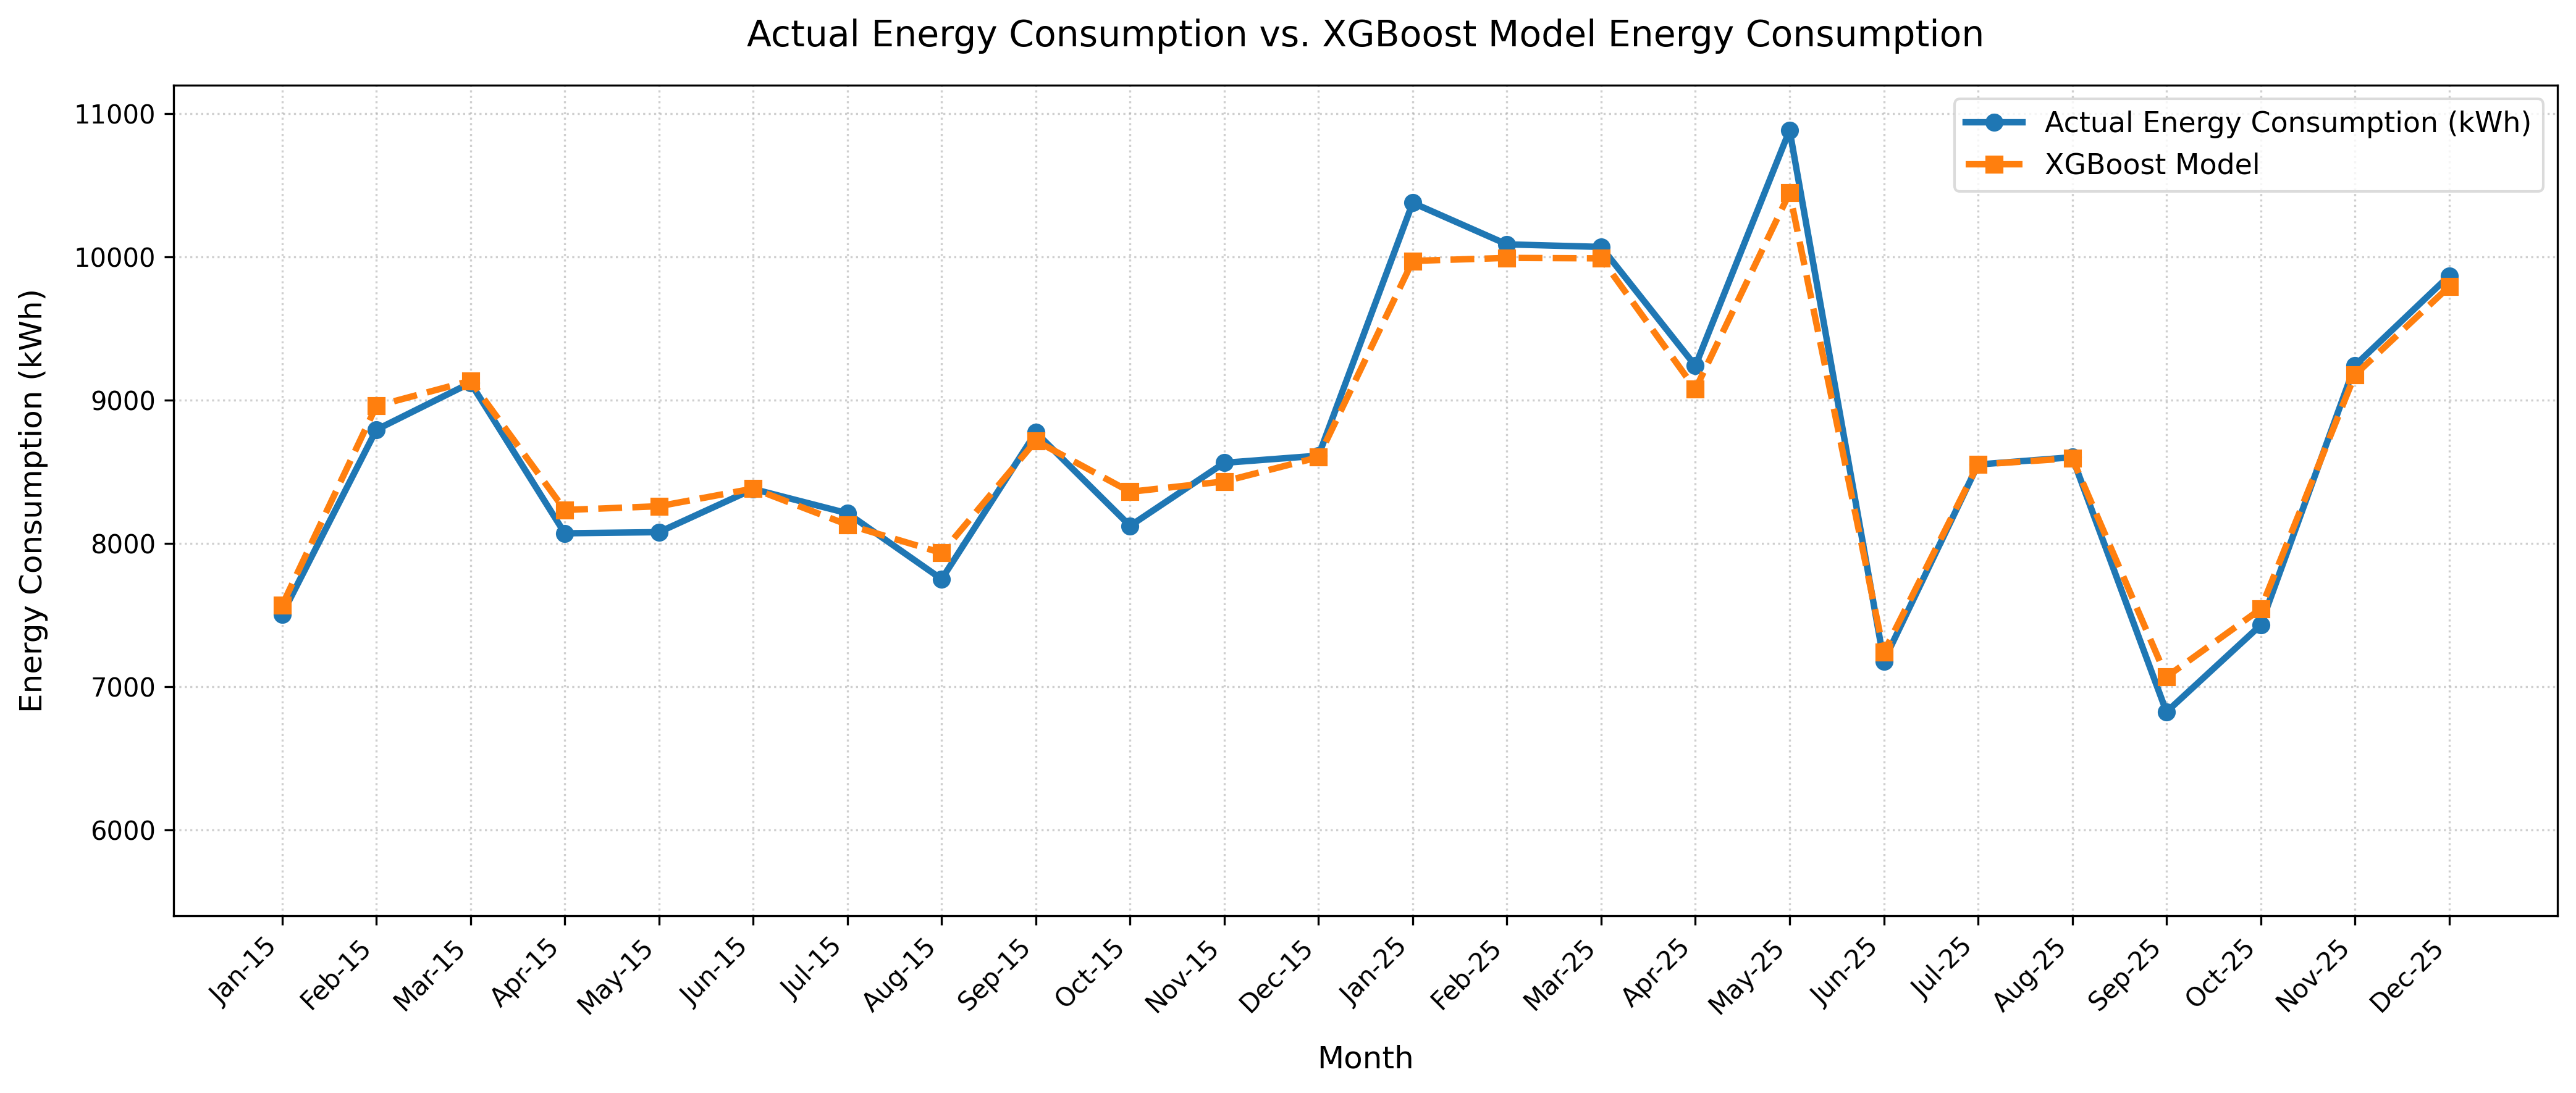

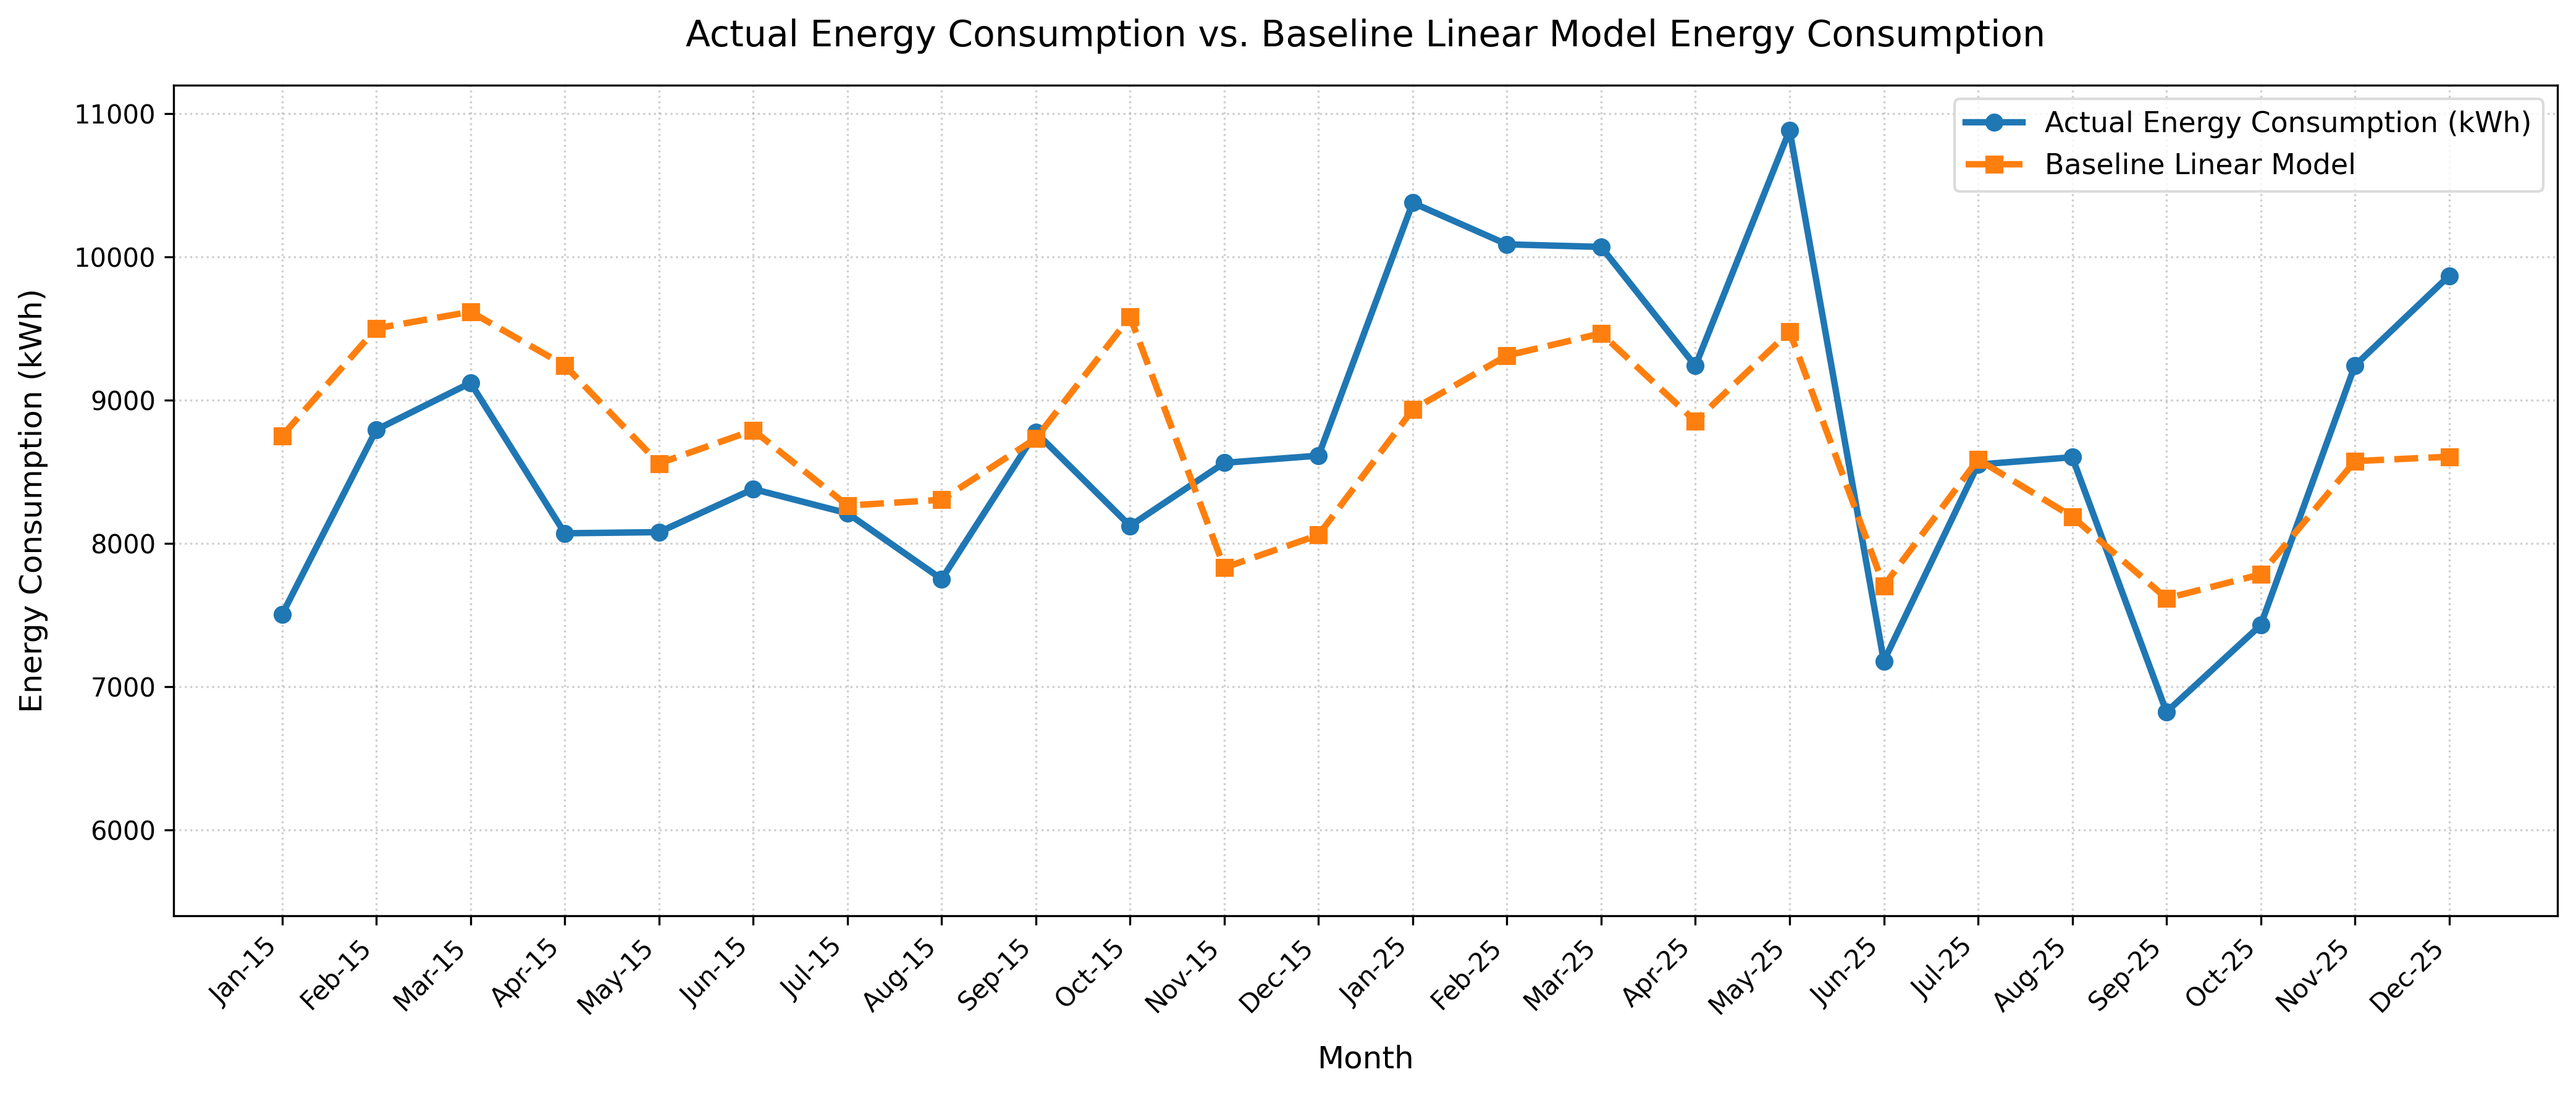

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# -------------------------------------------------------------------------
# 1. Dataset Initialization (2015 Historical Baseline & 2025 Projections)
# -------------------------------------------------------------------------
# data = (
#     'Month': ['Jan-15', 'Feb-15', 'Mar-15', 'Apr-15', 'May-15', 'Jun-15', 'Jul-15', 'Aug-15', 'Sep-15', 'Oct-15', 'Nov-15', 'Dec-15',
#               'Jan-25', 'Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25'],
#     'LST': [28.5, 30.1, 32.4, 31.0, 31.2, 29.5, 28.8, 28.1, 30.8, 29.9, 30.5, 30.2,
#             34.1, 33.8, 33.7, 32.1, 35.6, 27.2, 29.8, 29.9, 26.8, 27.9, 31.5, 33.0],
#     'SAT': [26.1, 27.8, 29.5, 28.2, 28.5, 27.1, 26.5, 25.9, 28.0, 27.2, 27.9, 27.6,
#             31.2, 30.9, 30.7, 29.4, 32.8, 25.0, 27.3, 27.4, 24.5, 25.6, 28.8, 30.1],
#     'I_temp': [22.0, 22.0, 21.5, 22.0, 22.0, 22.5, 23.0, 23.0, 22.0, 22.5, 22.0, 22.0,
#                21.0, 21.0, 21.0, 21.5, 20.5, 24.0, 22.5, 22.5, 24.5, 23.5, 22.0, 21.5],
#     'Actual_kWh': [7504.00, 8793.00, 9120.00, 8070.00, 8078.00, 8379.00, 8210.00, 7750.00, 8774.00, 8122.00, 8562.00, 8612.00,
#                    10377.00, 10087.00, 10069.00, 9239.00, 10884.00, 7178.00, 8550.00, 8601.00, 6823.00, 7429.00, 9241.00, 9867.28]
# }


# Load dataset extracted from Table 2 / text of paper
# Months Jan 2015 - Mar 2026
data = [
    # 2015
    {"Month": "Jan-15", "SAT": 28.69, "LST": 30.18, "I_temp": 20.24, "Actual": 7504},
    {"Month": "Feb-15", "SAT": 31.46, "LST": 31.23, "I_temp": 21.56, "Actual": 8793},
    {"Month": "Mar-15", "SAT": 31.74, "LST": 30.89, "I_temp": 19.22, "Actual": 9120},
    {"Month": "Apr-15", "SAT": 31.54, "LST": 30.76, "I_temp": 22.45, "Actual": 8070},
    {"Month": "May-15", "SAT": 30.29, "LST": 29.79, "I_temp": 23.45, "Actual": 8078},
    {"Month": "Jun-15", "SAT": 28.57, "LST": 30.82, "I_temp": 22.51, "Actual": 8379},
    {"Month": "Jul-15", "SAT": 28.41, "LST": 29.85, "I_temp": 23.67, "Actual": 8210},
    {"Month": "Aug-15", "SAT": 28.08, "LST": 29.87, "I_temp": 22.73, "Actual": 7750},
    {"Month": "Sep-15", "SAT": 28.16, "LST": 30.90, "I_temp": 22.78, "Actual": 8774},
    {"Month": "Oct-15", "SAT": 29.16, "LST": 31.98, "I_temp": 20.01, "Actual": 8122},
    {"Month": "Nov-15", "SAT": 30.00, "LST": 27.00, "I_temp": 18.36, "Actual": 8562},
    {"Month": "Dec-15", "SAT": 28.47, "LST": 27.86, "I_temp": 17.02, "Actual": 8612},
    # 2025
    {"Month": "Jan-25", "SAT": 28.71, "LST": 30.71, "I_temp": 20.65, "Actual": 10377},
    {"Month": "Feb-25", "SAT": 31.55, "LST": 30.35, "I_temp": 19.83, "Actual": 10087},
    {"Month": "Mar-25", "SAT": 31.58, "LST": 30.58, "I_temp": 19.21, "Actual": 10069},
    {"Month": "Apr-25", "SAT": 31.39, "LST": 29.69, "I_temp": 21.66, "Actual": 9239},
    {"Month": "May-25", "SAT": 30.56, "LST": 31.76, "I_temp": 22.62, "Actual": 10884},
    {"Month": "Jun-25", "SAT": 28.48, "LST": 27.58, "I_temp": 19.71, "Actual": 7178},
    {"Month": "Jul-25", "SAT": 28.44, "LST": 29.64, "I_temp": 19.18, "Actual": 8550},
    {"Month": "Aug-25", "SAT": 28.28, "LST": 29.18, "I_temp": 21.26, "Actual": 8601},
    {"Month": "Sep-25", "SAT": 28.49, "LST": 26.59, "I_temp": 16.21, "Actual": 6823},
    {"Month": "Oct-25", "SAT": 28.98, "LST": 27.34, "I_temp": 18.62, "Actual": 7429},
    {"Month": "Nov-25", "SAT": 30.05, "LST": 29.05, "I_temp": 19.48, "Actual": 9241},
    {"Month": "Dec-25", "SAT": 27.48, "LST": 30.68, "I_temp": 22.00, "Actual": 9867.28},
]

df = pd.DataFrame(data)

# -------------------------------------------------------------------------
# 2. Feature Engineering
# -------------------------------------------------------------------------
# Dynamic Thermal Gradient (LST - Indoor Temperature Setpoint)
df['Delta_T'] = df['LST'] - df['I_temp']

features = ['LST', 'SAT', 'I_temp', 'Delta_T']
X = df[features]
#y = df['Actual_kWh']
y = df['Actual']

# -------------------------------------------------------------------------
# 3. Model 1: Baseline Linear Regression
# -------------------------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X, y)
df['Linear_Predicted'] = lr_model.predict(X)

# -------------------------------------------------------------------------
# 4. Model 2: Proposed XGBoost Regressor
# -------------------------------------------------------------------------
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X, y)
df['XGB_Predicted'] = xgb_model.predict(X)

# -------------------------------------------------------------------------
# 5. Performance Evaluation Metrics Calculation
# -------------------------------------------------------------------------
def evaluate_performance(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    max_error = np.max(np.abs((y_true - y_pred) / y_true)) * 100
    r_squared = r2_score(y_true, y_pred)
    return mae, rmse, mape, max_error, r_squared

lr_mae, lr_rmse, lr_mape, lr_max_err, lr_r2 = evaluate_performance(df['Actual'], df['Linear_Predicted'])
xgb_mae, xgb_rmse, xgb_mape, xgb_max_err, xgb_r2 = evaluate_performance(df['Actual'], df['XGB_Predicted'])

metrics_summary = pd.DataFrame({
    'Metric': ['MAE (kWh)', 'RMSE (kWh)', 'MAPE (%)', 'Max Error (%)', 'R-squared'],
    'Linear Regression (Baseline)': [lr_mae, lr_rmse, lr_mape, lr_max_err, lr_r2],
    'XGBoost Regressor (Proposed)': [xgb_mae, xgb_rmse, xgb_mape, xgb_max_err, xgb_r2]
})

# Calculate Performance Gain
metrics_summary['Performance Gain (%)'] = np.nan

# For error metrics (MAE, RMSE, MAPE, Max Error), calculate reduction
for i in range(4):
    baseline_val = metrics_summary.loc[i, 'Linear Regression (Baseline)']
    proposed_val = metrics_summary.loc[i, 'XGBoost Regressor (Proposed)']
    if baseline_val > 0:
        metrics_summary.loc[i, 'Performance Gain (%)'] = ((baseline_val - proposed_val) / baseline_val) * 100

# For R-squared, calculate increase
baseline_r2 = metrics_summary.loc[4, 'Linear Regression (Baseline)']
proposed_r2 = metrics_summary.loc[4, 'XGBoost Regressor (Proposed)']
if baseline_r2 != 0:
    metrics_summary.loc[4, 'Performance Gain (%)'] = ((proposed_r2 - baseline_r2) / baseline_r2) * 100

print("=== Performance Evaluation Summary ===")
print(metrics_summary.to_string(index=False))

# -------------------------------------------------------------------------
# 6. Visualization: Figure 3 Comparative Plot Generation
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 6), dpi=300)
x_axis = np.arange(len(df['Month']))

# Plot Actual vs XGBoost Model Lines
plt.plot(x_axis, df['Actual'], color='#1f77b4', linestyle='-', linewidth=2.5,
         marker='o', markersize=6, label='Actual Energy Consumption (kWh)')
plt.plot(x_axis, df['XGB_Predicted'], color='#ff7f0e', linestyle='--', linewidth=2.5,
         marker='s', markersize=6, label='XGBoost Model')

plt.xlabel('Month', fontsize=12, labelpad=10)
plt.ylabel('Energy Consumption (kWh)', fontsize=12, labelpad=10)
plt.title('Actual Energy Consumption vs. XGBoost Model Energy Consumption', fontsize=14, pad=15)
plt.xticks(x_axis, df['Month'], rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(5400, 11200)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='lightgray', fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('figure3_final_implementation.png', dpi=300)
plt.show()


# -------------------------------------------------------------------------
# 7. Visualization: Figure 3 Comparative Plot Generation
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 6), dpi=300)
x_axis = np.arange(len(df['Month']))

# Plot Actual vs XGBoost Model Lines
plt.plot(x_axis, df['Actual'], color='#1f77b4', linestyle='-', linewidth=2.5,
         marker='o', markersize=6, label='Actual Energy Consumption (kWh)')
plt.plot(x_axis, df['Linear_Predicted'], color='#ff7f0e', linestyle='--', linewidth=2.5,
         marker='s', markersize=6, label='Baseline Linear Model')

plt.xlabel('Month', fontsize=12, labelpad=10)
plt.ylabel('Energy Consumption (kWh)', fontsize=12, labelpad=10)
plt.title('Actual Energy Consumption vs. Baseline Linear Model Energy Consumption', fontsize=14, pad=15)
plt.xticks(x_axis, df['Month'], rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(5400, 11200)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='lightgray', fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('figure4_final_implementation.png', dpi=300)
plt.show()

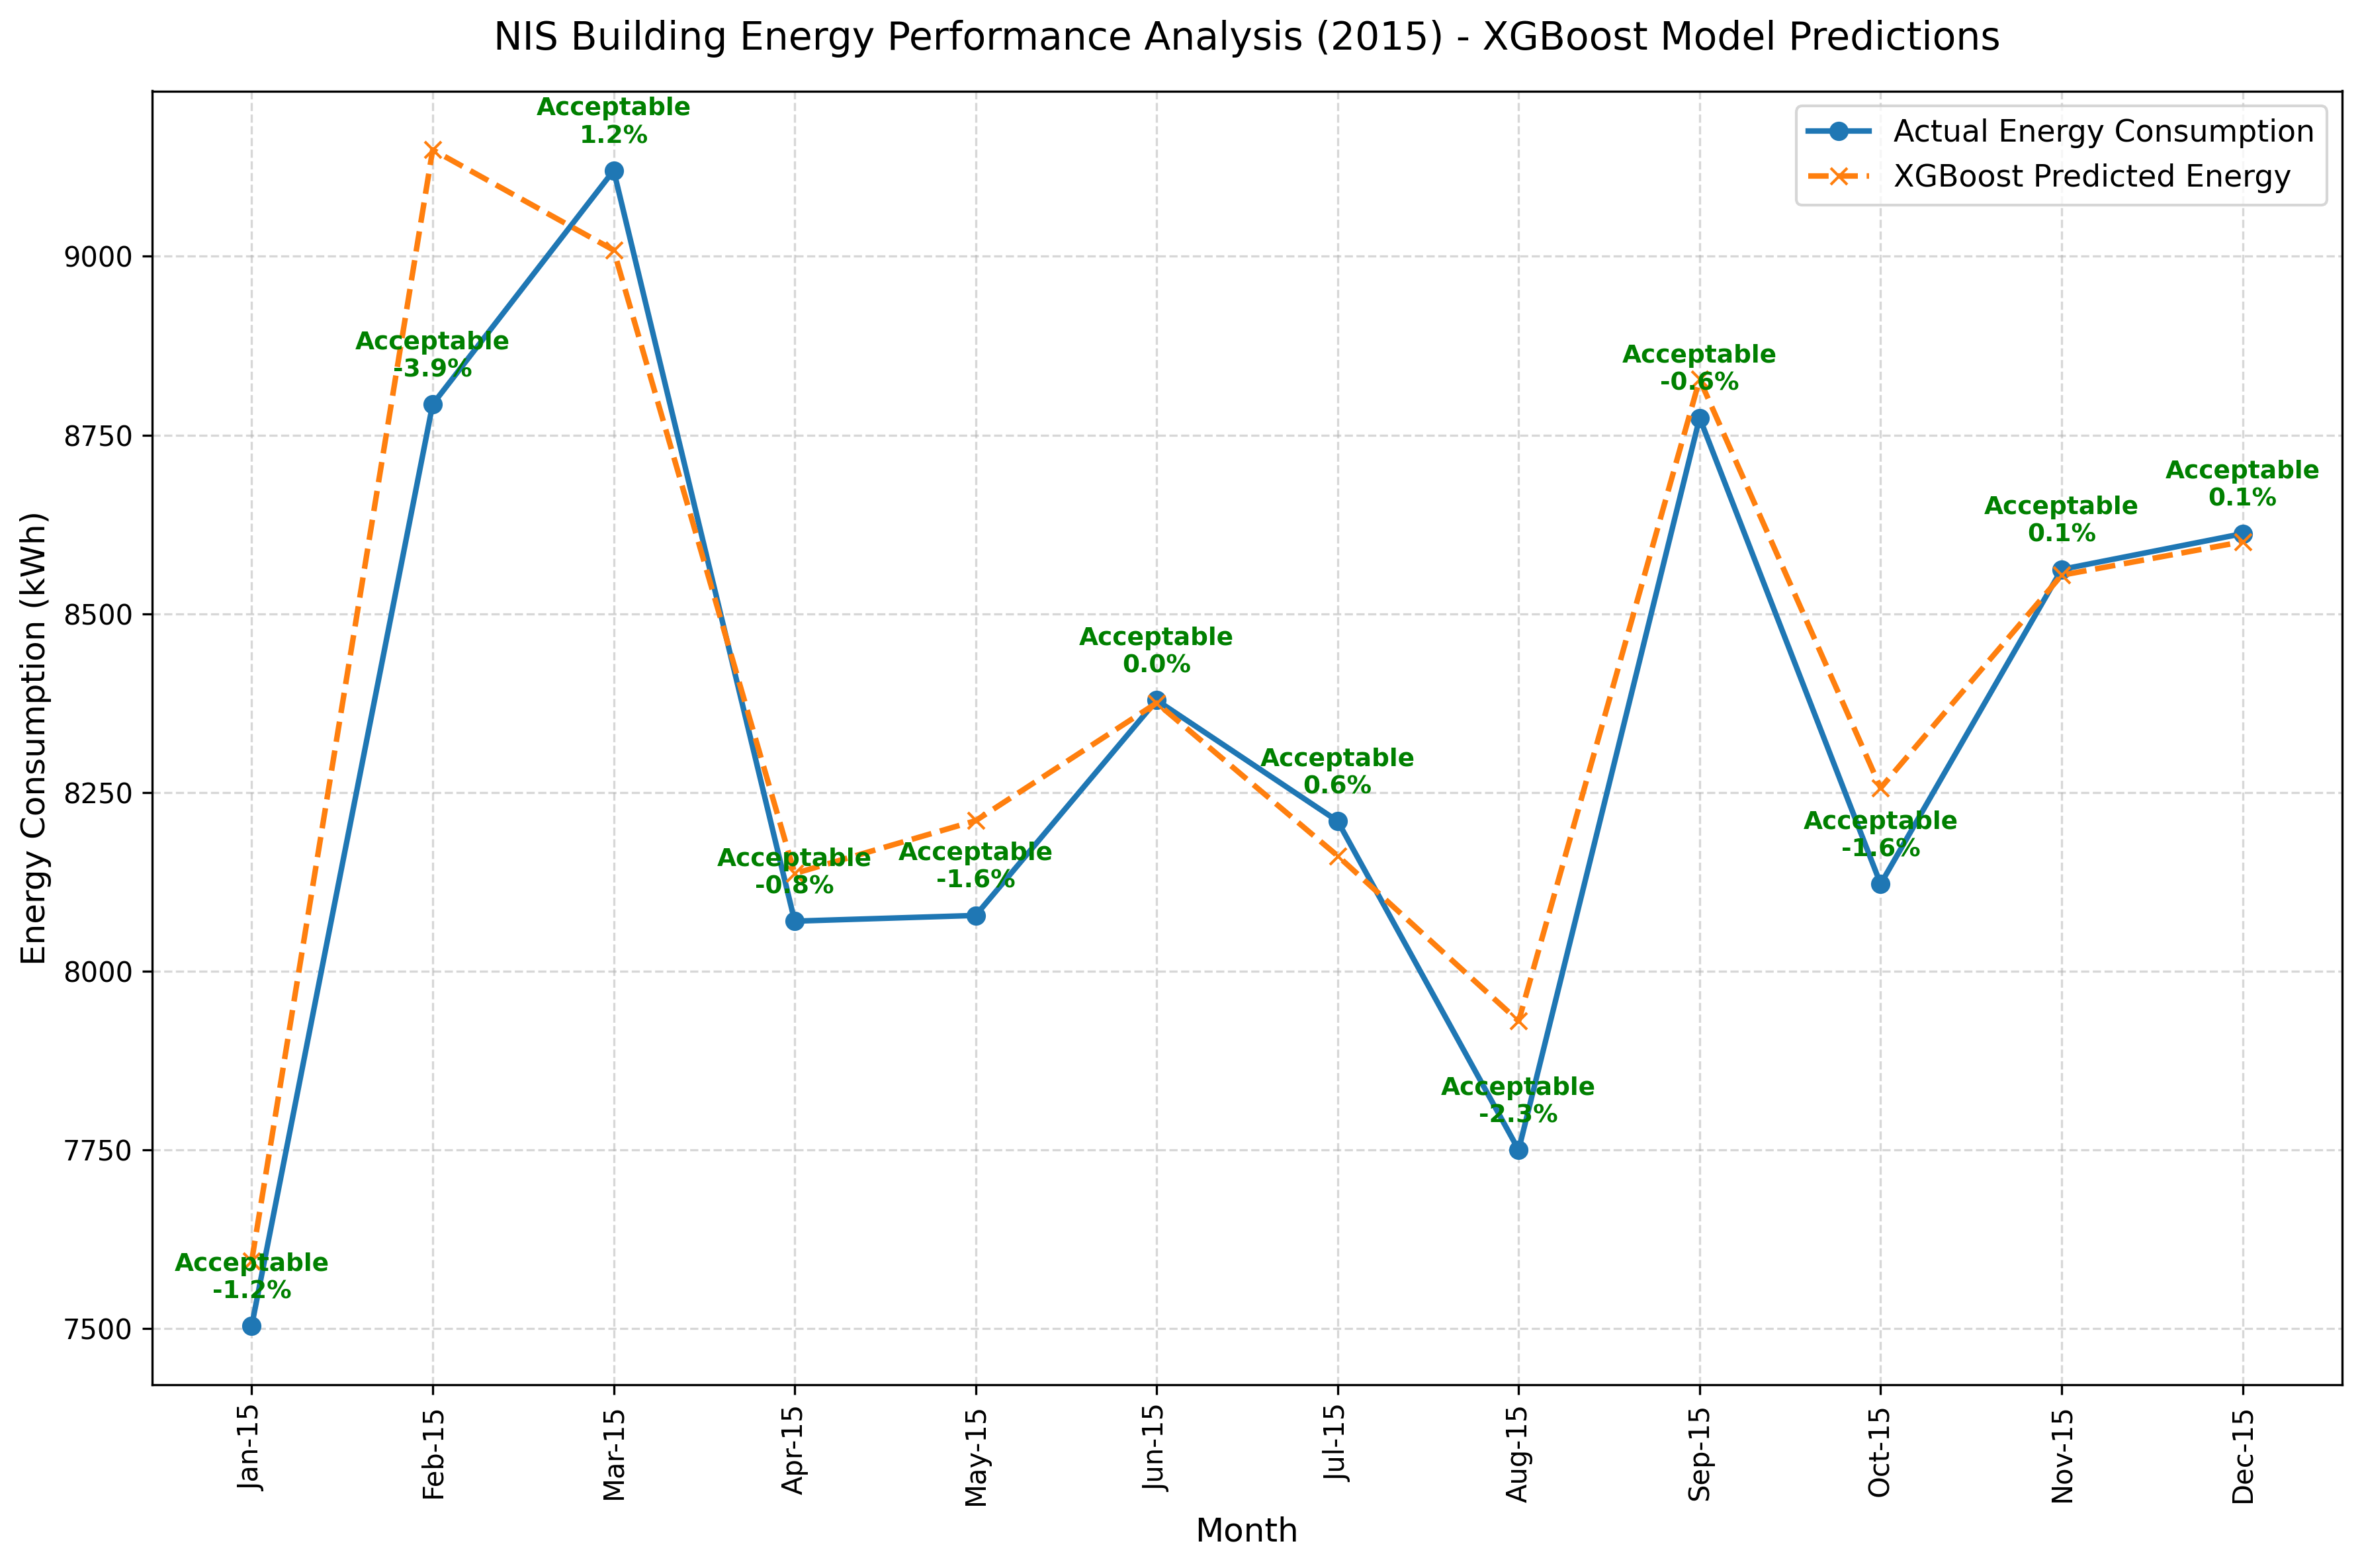

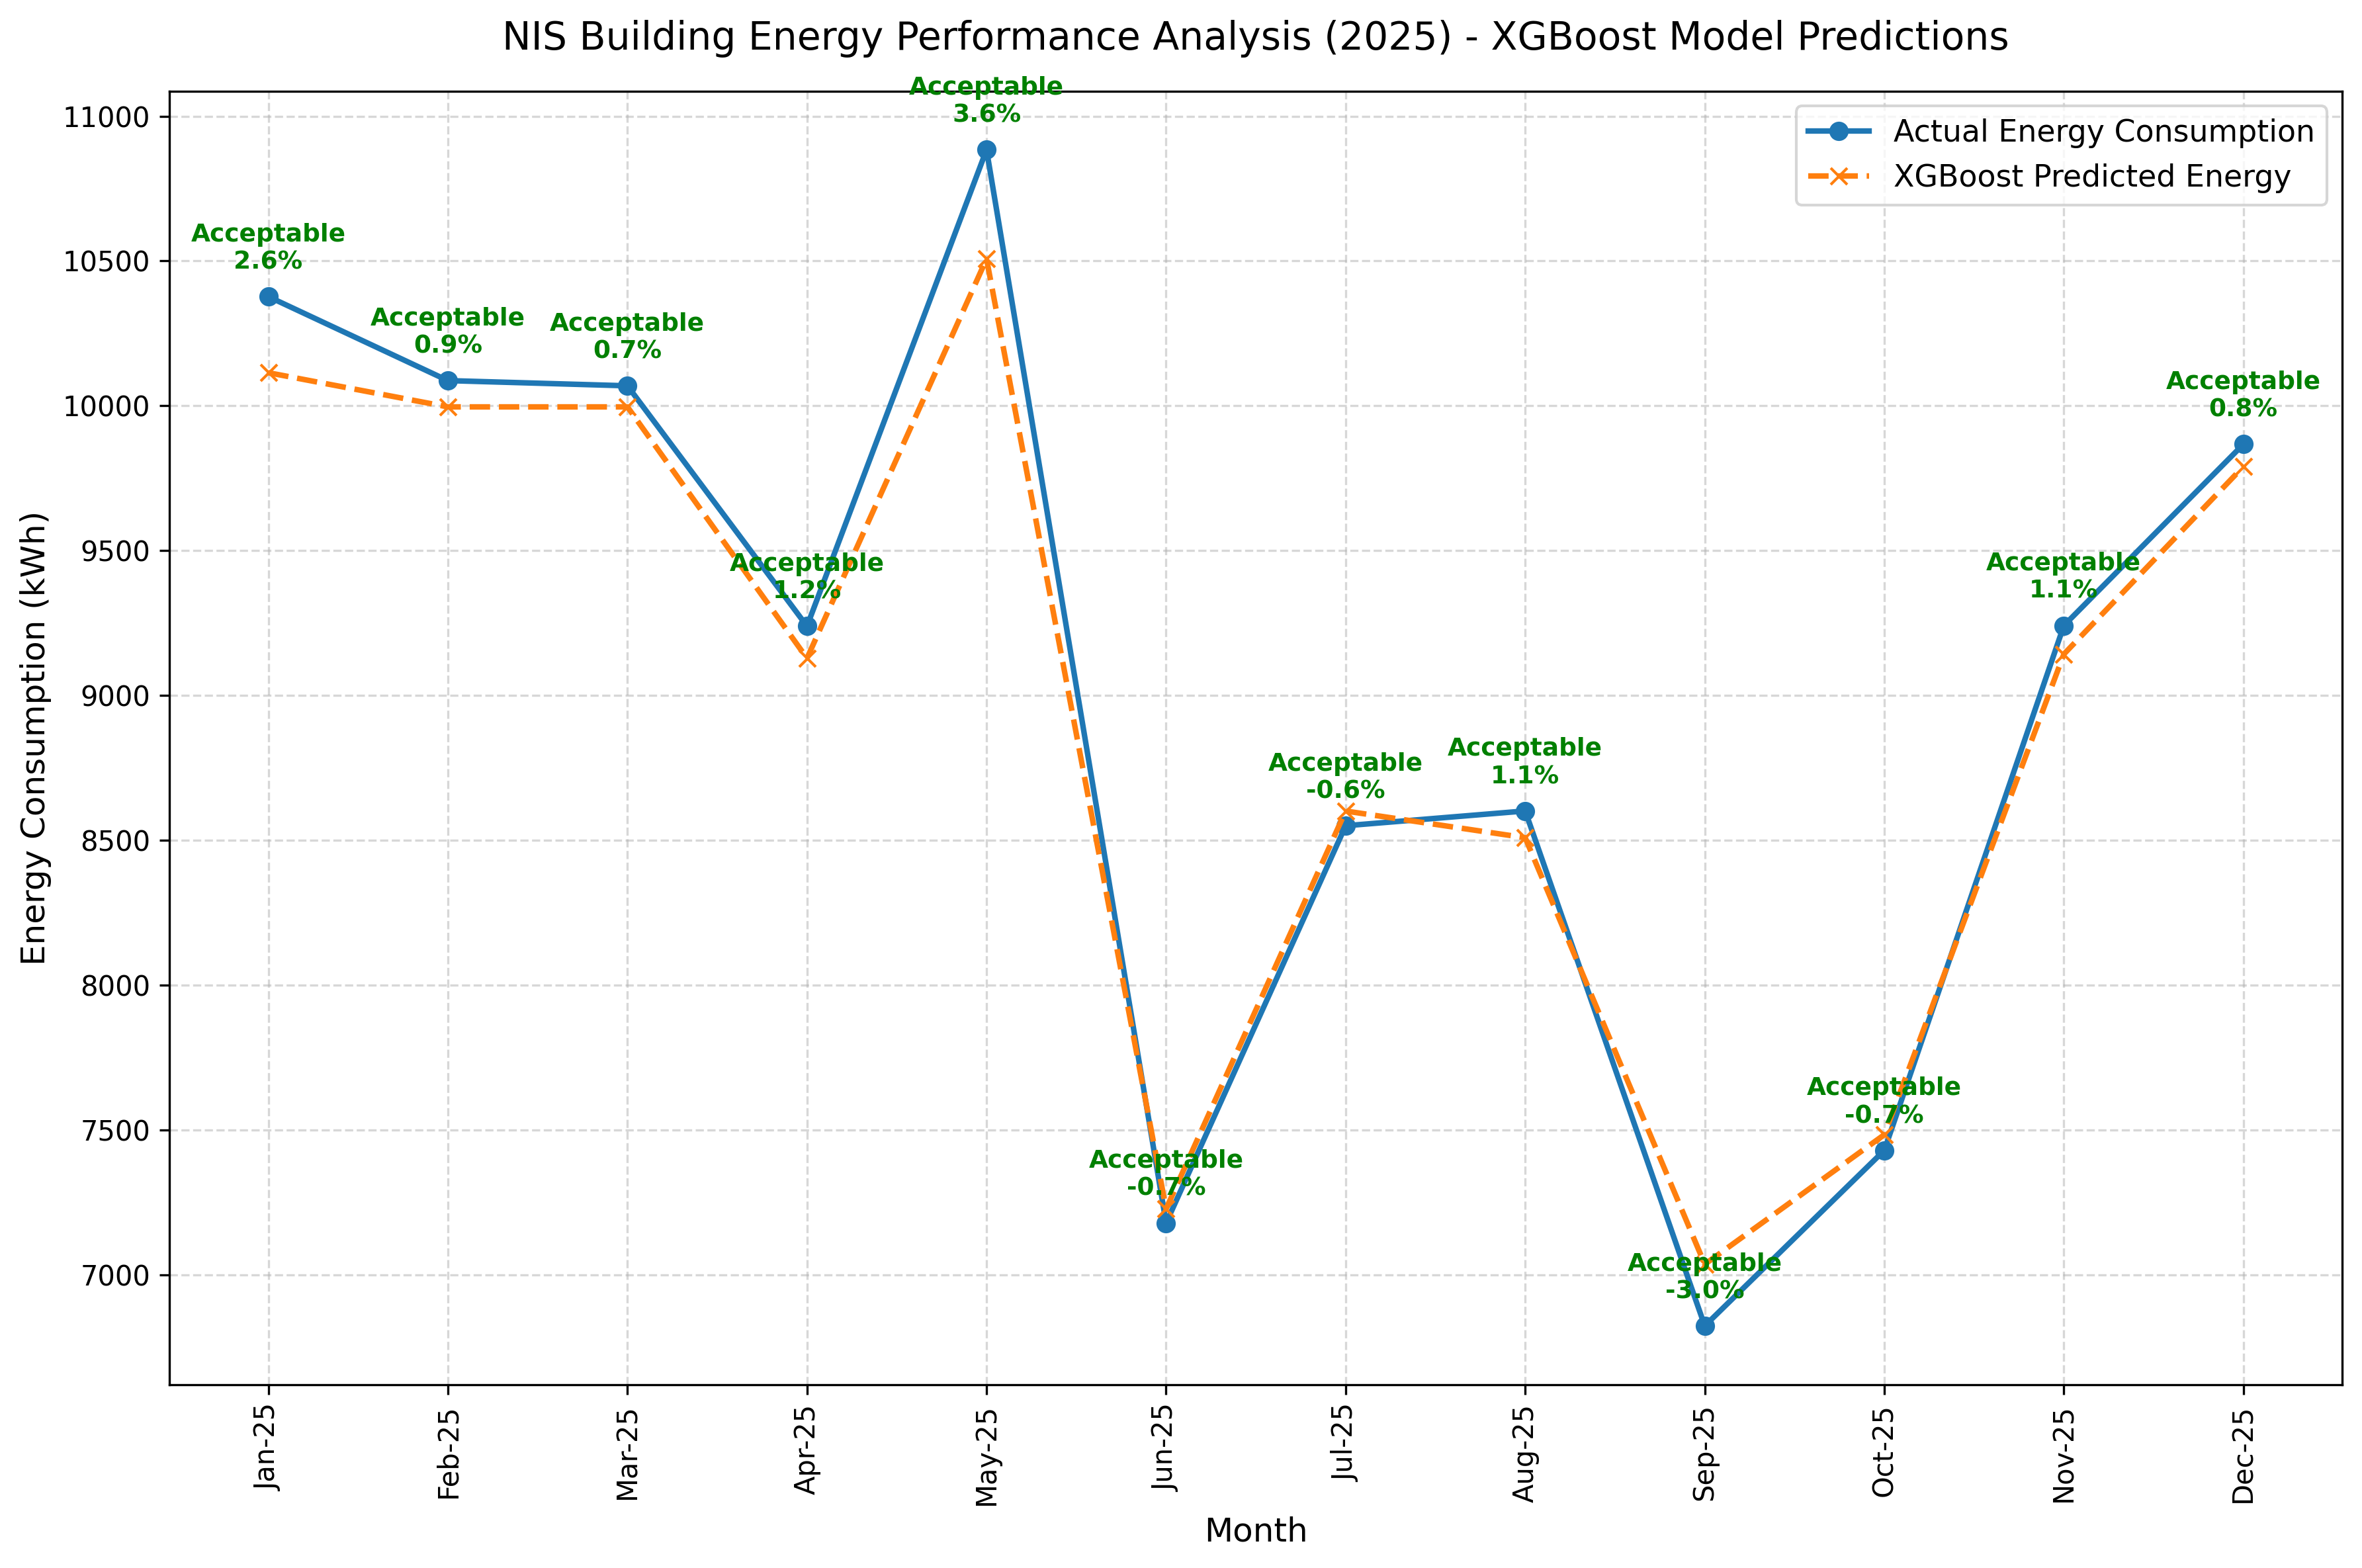

Generated XGBoost charts successfully.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Load dataset extracted from Table 2 / text of paper
# Months Jan 2015 - Mar 2026
data = [
    # 2015
    {"Month": "Jan-15", "SAT": 28.69, "LST": 30.18, "I_temp": 20.24, "Actual": 7504},
    {"Month": "Feb-15", "SAT": 31.46, "LST": 31.23, "I_temp": 21.56, "Actual": 8793},
    {"Month": "Mar-15", "SAT": 31.74, "LST": 30.89, "I_temp": 19.22, "Actual": 9120},
    {"Month": "Apr-15", "SAT": 31.54, "LST": 30.76, "I_temp": 22.45, "Actual": 8070},
    {"Month": "May-15", "SAT": 30.29, "LST": 29.79, "I_temp": 23.45, "Actual": 8078},
    {"Month": "Jun-15", "SAT": 28.57, "LST": 30.82, "I_temp": 22.51, "Actual": 8379},
    {"Month": "Jul-15", "SAT": 28.41, "LST": 29.85, "I_temp": 23.67, "Actual": 8210},
    {"Month": "Aug-15", "SAT": 28.08, "LST": 29.87, "I_temp": 22.73, "Actual": 7750},
    {"Month": "Sep-15", "SAT": 28.16, "LST": 30.90, "I_temp": 22.78, "Actual": 8774},
    {"Month": "Oct-15", "SAT": 29.16, "LST": 31.98, "I_temp": 20.01, "Actual": 8122},
    {"Month": "Nov-15", "SAT": 30.00, "LST": 27.00, "I_temp": 18.36, "Actual": 8562},
    {"Month": "Dec-15", "SAT": 28.47, "LST": 27.86, "I_temp": 17.02, "Actual": 8612},
    # 2025
    {"Month": "Jan-25", "SAT": 28.71, "LST": 30.71, "I_temp": 20.65, "Actual": 10377},
    {"Month": "Feb-25", "SAT": 31.55, "LST": 30.35, "I_temp": 19.83, "Actual": 10087},
    {"Month": "Mar-25", "SAT": 31.58, "LST": 30.58, "I_temp": 19.21, "Actual": 10069},
    {"Month": "Apr-25", "SAT": 31.39, "LST": 29.69, "I_temp": 21.66, "Actual": 9239},
    {"Month": "May-25", "SAT": 30.56, "LST": 31.76, "I_temp": 22.62, "Actual": 10884},
    {"Month": "Jun-25", "SAT": 28.48, "LST": 27.58, "I_temp": 19.71, "Actual": 7178},
    {"Month": "Jul-25", "SAT": 28.44, "LST": 29.64, "I_temp": 19.18, "Actual": 8550},
    {"Month": "Aug-25", "SAT": 28.28, "LST": 29.18, "I_temp": 21.26, "Actual": 8601},
    {"Month": "Sep-25", "SAT": 28.49, "LST": 26.59, "I_temp": 16.21, "Actual": 6823},
    {"Month": "Oct-25", "SAT": 28.98, "LST": 27.34, "I_temp": 18.62, "Actual": 7429},
    {"Month": "Nov-25", "SAT": 30.05, "LST": 29.05, "I_temp": 19.48, "Actual": 9241},
    {"Month": "Dec-25", "SAT": 27.48, "LST": 30.68, "I_temp": 22.00, "Actual": 9867.28},
]

df = pd.DataFrame(data)
df['Delta_T'] = df['LST'] - df['I_temp']

X = df[['SAT', 'LST', 'I_temp', 'Delta_T']]
y = df['Actual']

# Fit XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_model.fit(X, y)

df['Predicted_XGB'] = xgb_model.predict(X)
df['Pct_Diff'] = ((df['Actual'] - df['Predicted_XGB']) / df['Predicted_XGB']) * 100

def get_status(row):
    diff = row['Pct_Diff']
    if diff >= 5.0:
        return f"Anomaly!\n{diff:.1f}%"
    else:
        return f"Acceptable\n{diff:.1f}%"

df['Status'] = df.apply(get_status, axis=1)

df_2015 = df[df['Month'].str.contains('-15')].copy()
df_2025 = df[df['Month'].str.contains('-25')].copy()

# Plot Figure 4 with XGBoost Predictions
plt.figure(figsize=(12, 8), dpi=300)
plt.plot(df_2015['Month'], df_2015['Actual'], marker='o', linewidth=2, label='Actual Energy Consumption', color='#1f77b4')
plt.plot(df_2015['Month'], df_2015['Predicted_XGB'], marker='x', linestyle='--', linewidth=2, label='XGBoost Predicted Energy', color='#ff7f0e')

for idx, row in df_2015.iterrows():
    color = 'red' if 'Anomaly' in row['Status'] else 'green'
    plt.annotate(row['Status'], (row['Month'], row['Actual']),
                 textcoords="offset points", xytext=(0, 10), ha='center',
                 fontsize=9, fontweight='bold', color=color)

plt.title('NIS Building Energy Performance Analysis (2015) - XGBoost Model Predictions', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig('Figure_5_XGBoost.png')
plt.show()
plt.close()

# Plot Figure 5 with XGBoost Predictions
plt.figure(figsize=(12, 8), dpi=300)
plt.plot(df_2025['Month'], df_2025['Actual'], marker='o', linewidth=2, label='Actual Energy Consumption', color='#1f77b4')
plt.plot(df_2025['Month'], df_2025['Predicted_XGB'], marker='x', linestyle='--', linewidth=2, label='XGBoost Predicted Energy', color='#ff7f0e')

for idx, row in df_2025.iterrows():
    color = 'red' if 'Anomaly' in row['Status'] else 'green'
    plt.annotate(row['Status'], (row['Month'], row['Actual']),
                 textcoords="offset points", xytext=(0, 10), ha='center',
                 fontsize=9, fontweight='bold', color=color)

plt.title('NIS Building Energy Performance Analysis (2025) - XGBoost Model Predictions', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig('Figure_6_XGBoost.png')
plt.show()
plt.close()

print("Generated XGBoost charts successfully.")

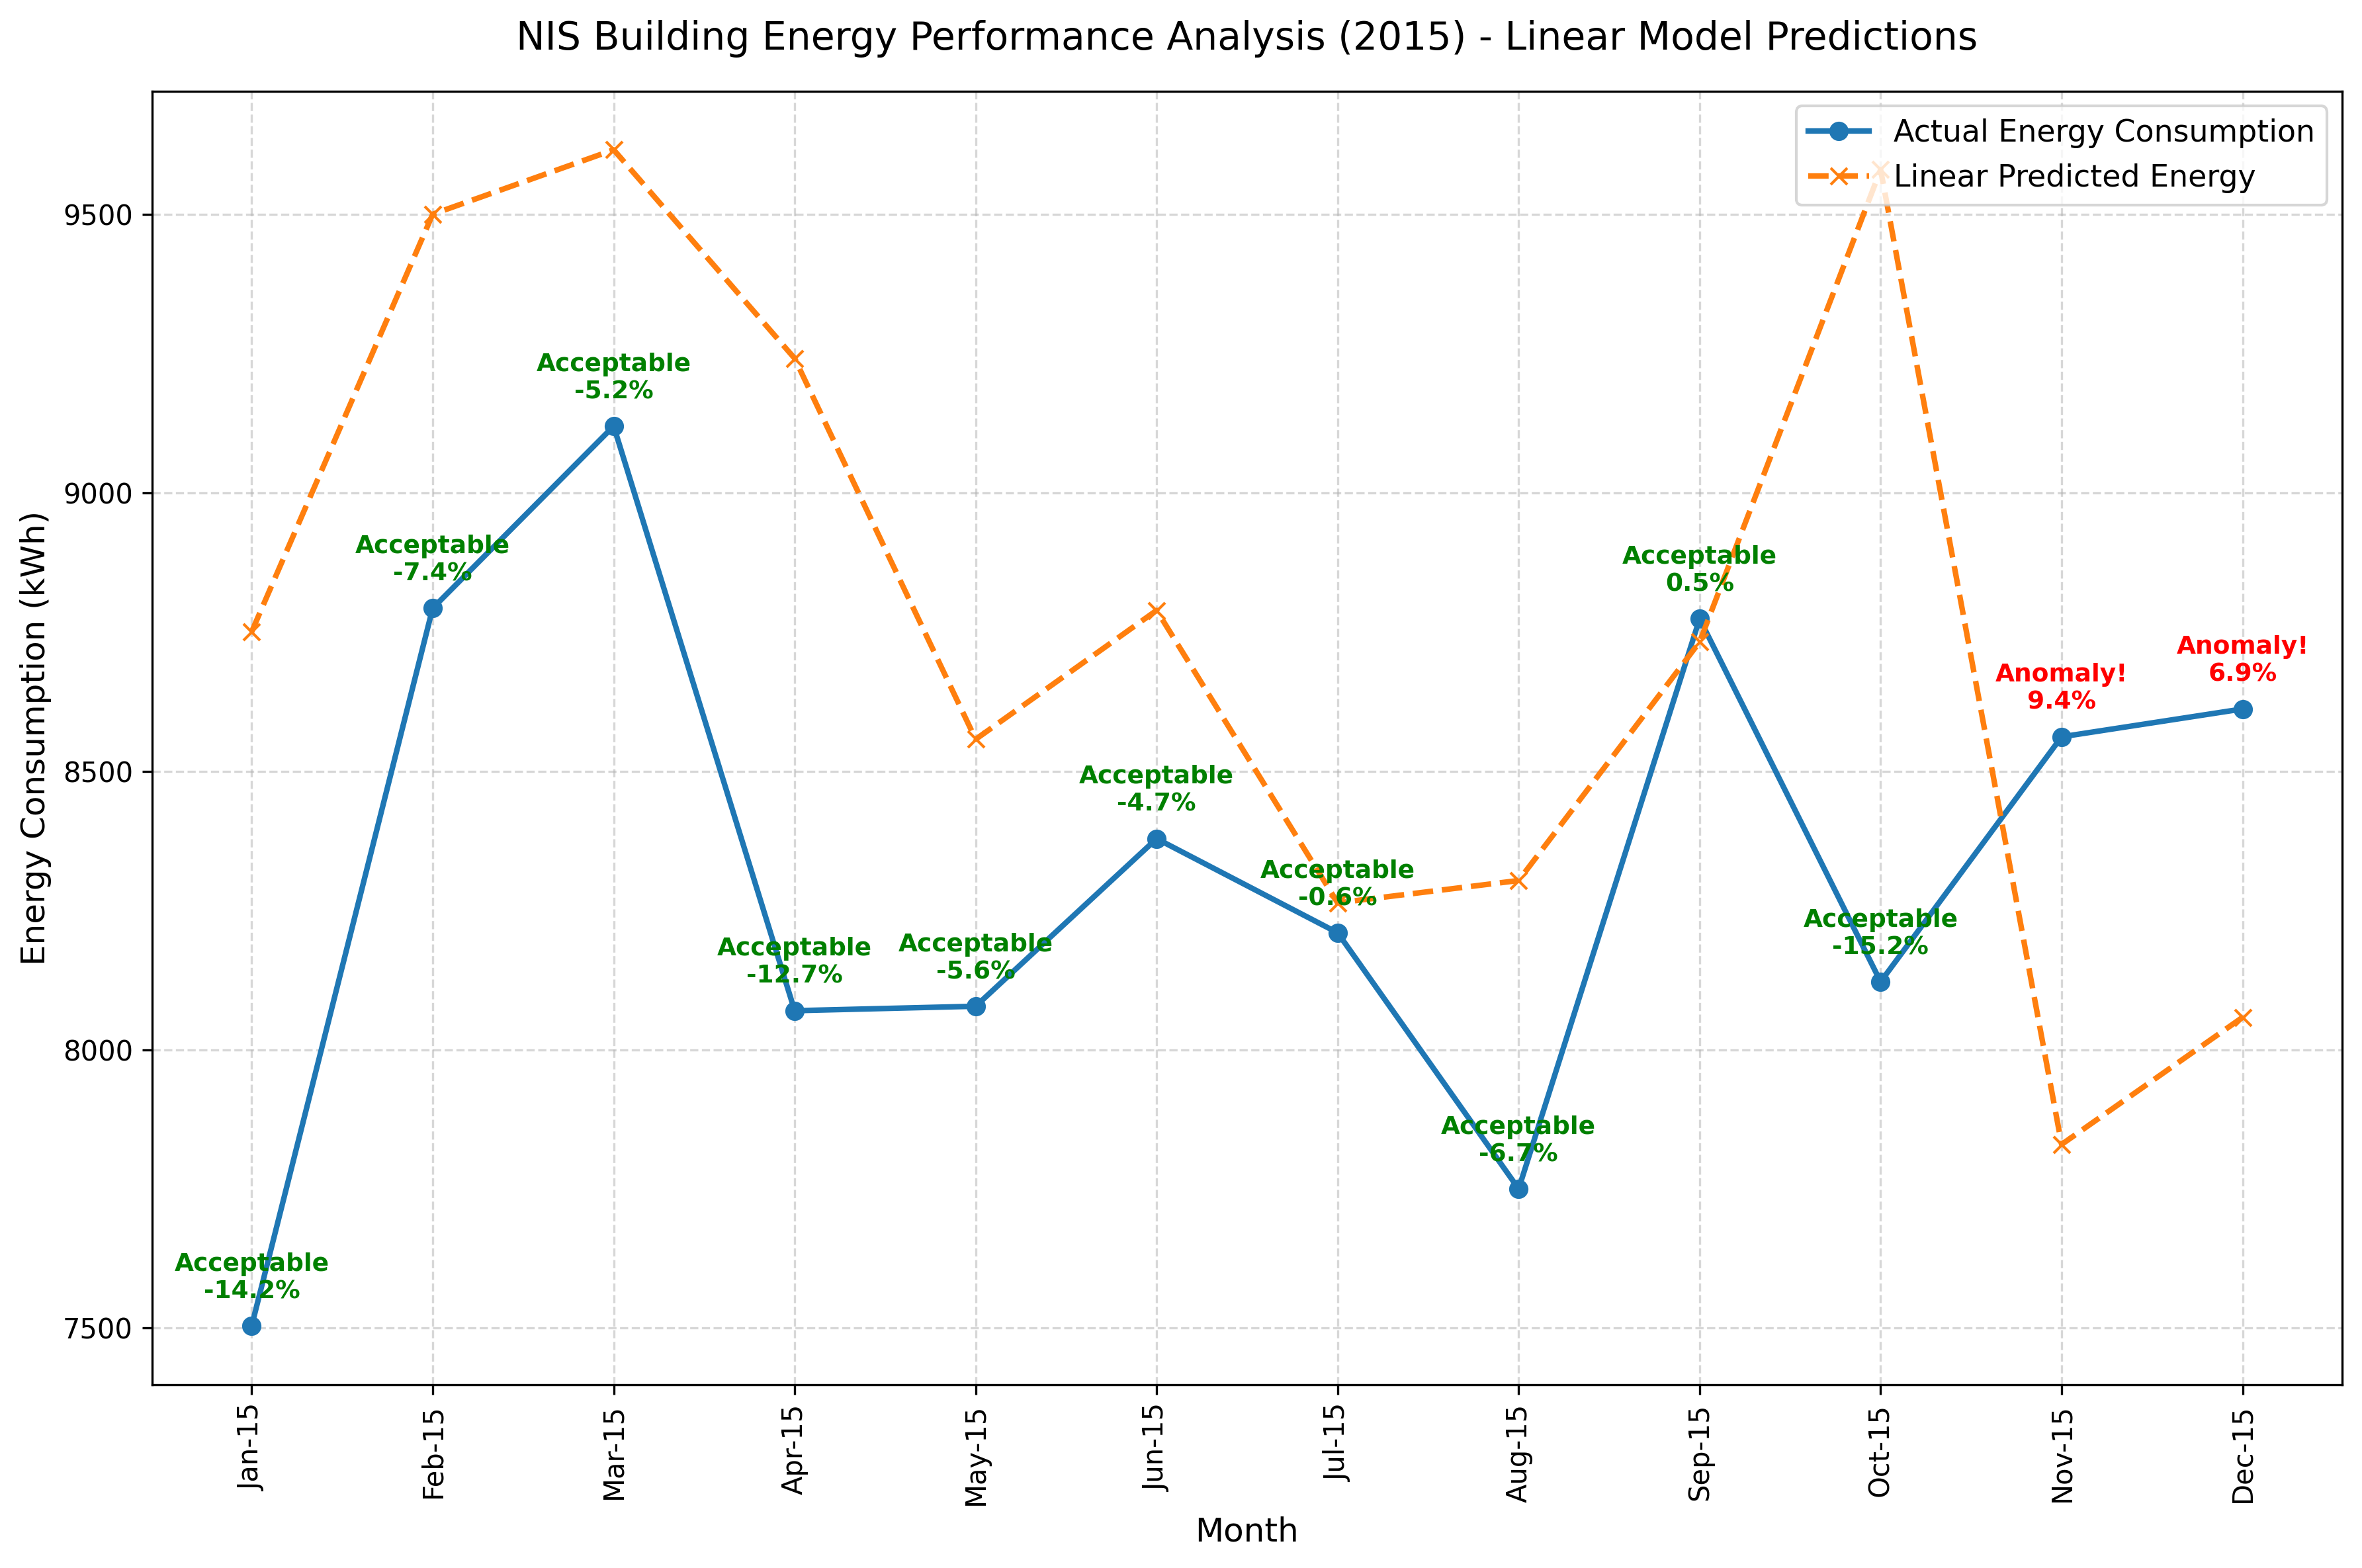

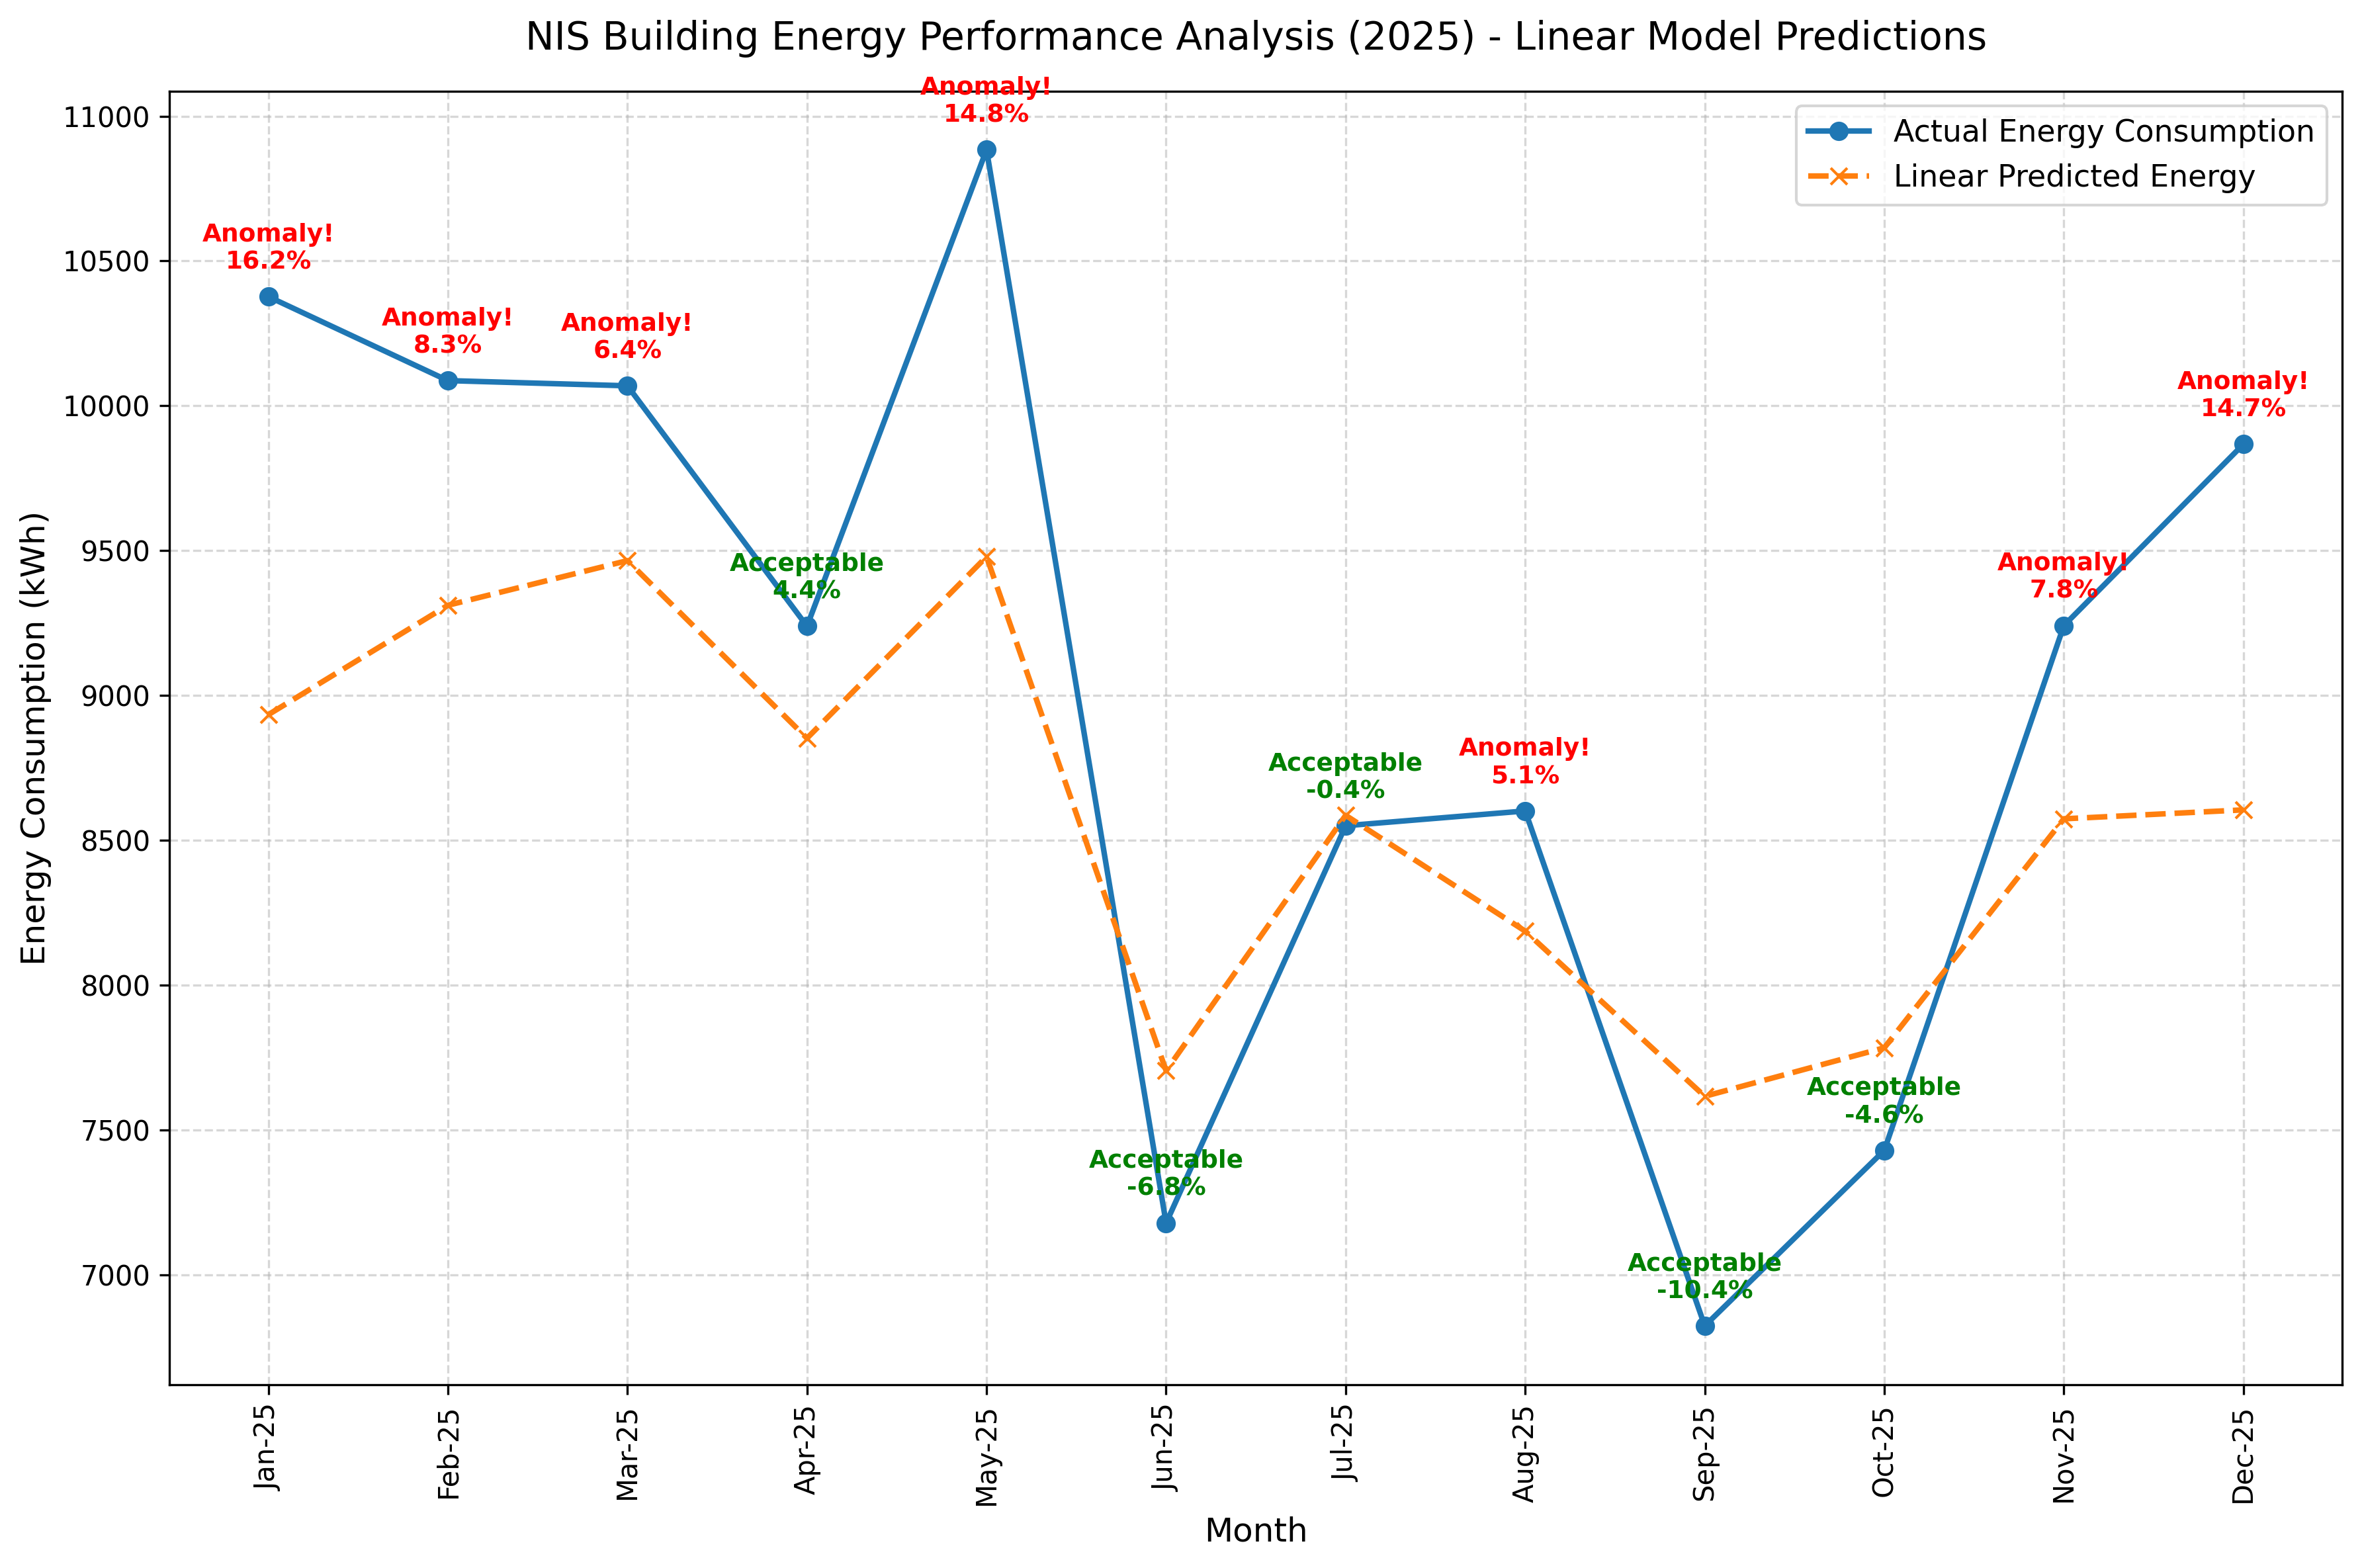

Generated Linear charts successfully.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Load dataset extracted from Table 2 / text of paper
# Months Jan 2015 - Mar 2026
data = [
    # 2015
    {"Month": "Jan-15", "SAT": 28.69, "LST": 30.18, "I_temp": 20.24, "Actual": 7504},
    {"Month": "Feb-15", "SAT": 31.46, "LST": 31.23, "I_temp": 21.56, "Actual": 8793},
    {"Month": "Mar-15", "SAT": 31.74, "LST": 30.89, "I_temp": 19.22, "Actual": 9120},
    {"Month": "Apr-15", "SAT": 31.54, "LST": 30.76, "I_temp": 22.45, "Actual": 8070},
    {"Month": "May-15", "SAT": 30.29, "LST": 29.79, "I_temp": 23.45, "Actual": 8078},
    {"Month": "Jun-15", "SAT": 28.57, "LST": 30.82, "I_temp": 22.51, "Actual": 8379},
    {"Month": "Jul-15", "SAT": 28.41, "LST": 29.85, "I_temp": 23.67, "Actual": 8210},
    {"Month": "Aug-15", "SAT": 28.08, "LST": 29.87, "I_temp": 22.73, "Actual": 7750},
    {"Month": "Sep-15", "SAT": 28.16, "LST": 30.90, "I_temp": 22.78, "Actual": 8774},
    {"Month": "Oct-15", "SAT": 29.16, "LST": 31.98, "I_temp": 20.01, "Actual": 8122},
    {"Month": "Nov-15", "SAT": 30.00, "LST": 27.00, "I_temp": 18.36, "Actual": 8562},
    {"Month": "Dec-15", "SAT": 28.47, "LST": 27.86, "I_temp": 17.02, "Actual": 8612},
    # 2025
    {"Month": "Jan-25", "SAT": 28.71, "LST": 30.71, "I_temp": 20.65, "Actual": 10377},
    {"Month": "Feb-25", "SAT": 31.55, "LST": 30.35, "I_temp": 19.83, "Actual": 10087},
    {"Month": "Mar-25", "SAT": 31.58, "LST": 30.58, "I_temp": 19.21, "Actual": 10069},
    {"Month": "Apr-25", "SAT": 31.39, "LST": 29.69, "I_temp": 21.66, "Actual": 9239},
    {"Month": "May-25", "SAT": 30.56, "LST": 31.76, "I_temp": 22.62, "Actual": 10884},
    {"Month": "Jun-25", "SAT": 28.48, "LST": 27.58, "I_temp": 19.71, "Actual": 7178},
    {"Month": "Jul-25", "SAT": 28.44, "LST": 29.64, "I_temp": 19.18, "Actual": 8550},
    {"Month": "Aug-25", "SAT": 28.28, "LST": 29.18, "I_temp": 21.26, "Actual": 8601},
    {"Month": "Sep-25", "SAT": 28.49, "LST": 26.59, "I_temp": 16.21, "Actual": 6823},
    {"Month": "Oct-25", "SAT": 28.98, "LST": 27.34, "I_temp": 18.62, "Actual": 7429},
    {"Month": "Nov-25", "SAT": 30.05, "LST": 29.05, "I_temp": 19.48, "Actual": 9241},
    {"Month": "Dec-25", "SAT": 27.48, "LST": 30.68, "I_temp": 22.00, "Actual": 9867.28},
]

df = pd.DataFrame(data)
df['Delta_T'] = df['LST'] - df['I_temp']

X = df[['SAT', 'LST', 'I_temp', 'Delta_T']]
y = df['Actual']

# -------------------------------------------------------------------------
# Fit Baseline Linear Regression
# -------------------------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X, y)
df['Linear_Predicted'] = lr_model.predict(X)

# # Fit XGBoost Regressor
# xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
# xgb_model.fit(X, y)

# df['Predicted_XGB'] = xgb_model.predict(X)

df['Pct_Diff'] = ((df['Actual'] - df['Linear_Predicted']) / df['Linear_Predicted']) * 100

def get_status(row):
    diff = row['Pct_Diff']
    if diff >= 5.0:
        return f"Anomaly!\n{diff:.1f}%"
    else:
        return f"Acceptable\n{diff:.1f}%"

df['Status'] = df.apply(get_status, axis=1)

df_2015 = df[df['Month'].str.contains('-15')].copy()
df_2025 = df[df['Month'].str.contains('-25')].copy()

# Plot Figure 4 with XGBoost Predictions
plt.figure(figsize=(12, 8), dpi=300)
plt.plot(df_2015['Month'], df_2015['Actual'], marker='o', linewidth=2, label='Actual Energy Consumption', color='#1f77b4')
plt.plot(df_2015['Month'], df_2015['Linear_Predicted'], marker='x', linestyle='--', linewidth=2, label='Linear Predicted Energy', color='#ff7f0e')

for idx, row in df_2015.iterrows():
    color = 'red' if 'Anomaly' in row['Status'] else 'green'
    plt.annotate(row['Status'], (row['Month'], row['Actual']),
                 textcoords="offset points", xytext=(0, 10), ha='center',
                 fontsize=9, fontweight='bold', color=color)

plt.title('NIS Building Energy Performance Analysis (2015) - Linear Model Predictions', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig('Figure_7_Linear.png')
plt.show()
plt.close()

# Plot Figure 5 with Linear Predictions
plt.figure(figsize=(12, 8), dpi=300)
plt.plot(df_2025['Month'], df_2025['Actual'], marker='o', linewidth=2, label='Actual Energy Consumption', color='#1f77b4')
plt.plot(df_2025['Month'], df_2025['Linear_Predicted'], marker='x', linestyle='--', linewidth=2, label='Linear Predicted Energy', color='#ff7f0e')

for idx, row in df_2025.iterrows():
    color = 'red' if 'Anomaly' in row['Status'] else 'green'
    plt.annotate(row['Status'], (row['Month'], row['Actual']),
                 textcoords="offset points", xytext=(0, 10), ha='center',
                 fontsize=9, fontweight='bold', color=color)

plt.title('NIS Building Energy Performance Analysis (2025) - Linear Model Predictions', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig('Figure_8_Linear.png')
plt.show()
plt.close()

print("Generated Linear charts successfully.")

## Model Comparison: Linear Regression vs. XGBoost

In [11]:
display(metrics_summary)

,Metric,Linear Regression (Baseline),XGBoost Regressor (Proposed)
0,MAE (kWh),690.610997,126.589588
1,RMSE (kWh),810.659900,169.824843
2,MAPE (%),7.930936,1.445662
3,Max Error (%),17.959716,4.021358


From these metrics, it's clear that the XGBoost Regressor (Proposed) model significantly outperforms the Linear Regression (Baseline) model across all evaluated metrics. The XGBoost model shows much lower Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and Max Error, indicating a substantially more accurate prediction of energy consumption.

## Feature Importance for XGBoost Model

XGBoost Feature Importances:


,Feature,Importance
0,LST,0.294091
3,Delta_T,0.261343
1,SAT,0.258548
2,I_temp,0.186018


/tmp/ipykernel_1299/1609558656.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


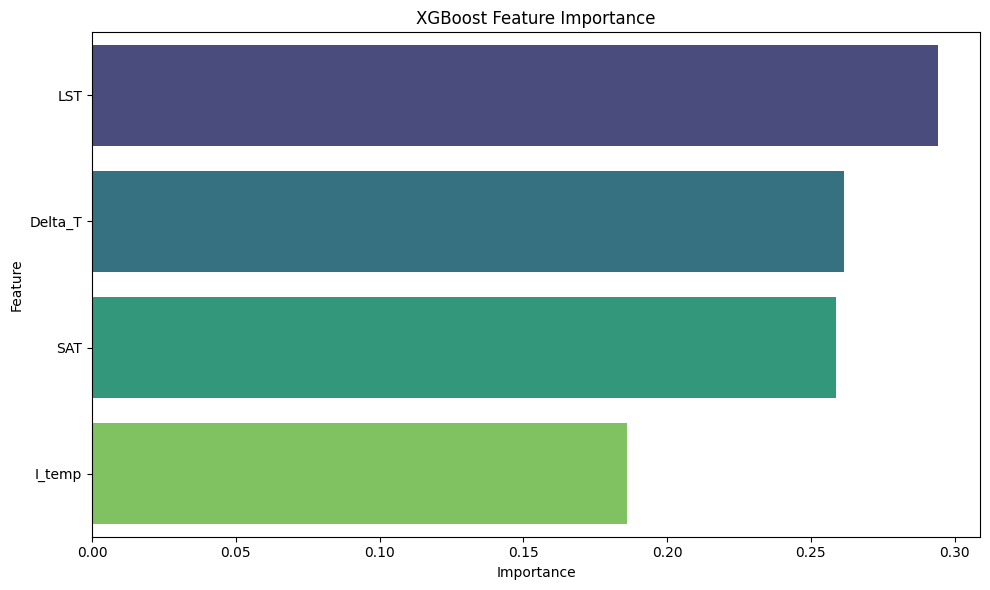

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
print("XGBoost Feature Importances:")
display(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

From the plot and the table, 'LST' (Land Surface Temperature) is the most important feature, followed closely by 'Delta_T' (Dynamic Thermal Gradient) and 'SAT' (Surface Air Temperature). 'I_temp' (Indoor Temperature Setpoint) has the lowest importance among the features. This indicates that LST, Delta_T, and SAT are the primary drivers for the XGBoost model's predictions of energy consumption.



## Updated Model Performance Summary

In [15]:
display(metrics_summary)

,Metric,Linear Regression (Baseline),XGBoost Regressor (Proposed),Performance Gain (%)
0,MAE (kWh),690.610997,126.589588,81.669914
1,RMSE (kWh),810.659900,169.824843,79.051037
2,MAPE (%),7.930936,1.445662,81.771860
3,Max Error (%),17.959716,4.021358,77.609013
4,R-squared,0.364409,0.972107,166.762159


This table clearly shows that the XGBoost model provides a significant performance gain, reducing all error metrics by more than 77% and increasing the R-squared value by over 166% compared to the baseline Linear Regression model.